In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [4]:
df = pd.read_csv("sales_january.csv")
df.head()

,Date,Item,Quantity,Sale
0,1/2/2026,Asparagus&Snow Pea,1,18.25
1,1/2/2026,Broccoli,1,15.95
2,1/2/2026,Brown Rice,5,5.00
3,1/2/2026,Canned Drinks ($2.00),4,8.00
4,1/2/2026,Cashew Nut,2,32.90


In [5]:
df.shape

(4375, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4375 entries, 0 to 4374
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      4375 non-null   object 
 1   Item      4375 non-null   object 
 2   Quantity  4375 non-null   int64  
 3   Sale      4375 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 136.8+ KB


In [7]:
df["Item"].unique()

array(['Asparagus&Snow Pea', 'Broccoli', 'Brown Rice',
       'Canned Drinks ($2.00)', 'Cashew Nut', 'Chow Mein', 'Cold Tea',
       'Crab Cheese', 'Curry Fried Rice', 'Drunken Noodle',
       'Dumpling (7)', 'Egg Rolls', 'Eggplant', 'Fresh Roll',
       'Fried Rice', 'Fried Tofu', 'Fried Wonton', 'Garlic Pepper',
       'Ginger Meat', 'Green Curry', 'JASMINE RICE', 'Jasmine Rice',
       'Khao Soi', 'Kids Chow Mein', 'Larb Salad', 'Mixed Vegetables',
       'Nam Sod Salad', 'Pad Prik Khing', 'Pad See Ew', 'Pad Thai',
       'Pad Woon Sen', 'Panang Curry', 'Papaya Salad', 'Pine Curry',
       'Pineapple Fried Rice', 'Pumpkin Curry', 'Ramune', 'Red Curry',
       'Satae', 'Shrimp Rolls', 'Shrimp Tempura (5)', 'Small Soda',
       'Spicy Basil', 'Spicy Fried Rice', 'Spinach Soup', 'Sweet & Sour',
       'Thai Fried Rice', 'Thai Green Tea', 'Thai Green Tea Large',
       'Thai Tea', 'Thai Tea Large', 'Tom Kha Gai', 'Tom Yum Gai',
       'Udon Pad Kee Mao', 'Vegetable Fried Rice', 'Vegetab

In [8]:
df[df["Item"] == "DELIVERY AT 5.30PM"]

,Date,Item,Quantity,Sale
3748,3/18/2026,DELIVERY AT 5.30PM,1,0.0


**Items to drop:**
'deliver by 11.30 am',
'PICK UP 5/5.30PM', 'PICK UP 5.45PM', 'pork soup',
'7 cooked shrimp', 'PICK UP 5.20', 'pick up 6.15', 'House Salad',
'PICK UP 12.15', 'pick up 6.30', 'pick up 6pm', 'PICK UP @5.45',
'Pick up 715', 'PICK UP @11.40AM',
'PICK UP AT 5PM', 'PICK UP @7.45PM', 'chin chin tea',
'PICK UP @11.45PM', 'PICK UP @7.0PM', 'PICK UP @6.30PM',
'pick up 1.45', 'PICK UP @4.50PM', 'PICK UP @7.15PM',
'DELIVERY AT 5.30PM', 'PICK UP 2.45', '5 shrimp',
'DELIVER AT 5.30PM', 'plus 1', 'pick up 5.30 pm',
'DELIVERY 11.45AM', 'PICK UP @5PM', PICK UP @6.15PM, etc.


In [37]:
list_items = [
    "Asparagus&Snow Pea",
    "Broccoli",
    "Brown Rice",
    "Canned Drinks ($2.00)",
    "Cashew Nut",
    "Chow Mein",
    "Cold Tea",
    "Crab Cheese",
    "Curry Fried Rice",
    "Drunken Noodle",
    "Dumpling (7)",
    "Egg Rolls",
    "Eggplant",
    "Fresh Roll",
    "Fried Rice",
    "Fried Tofu",
    "Fried Wonton",
    "Garlic Pepper",
    "Ginger Meat",
    "Green Curry",
    "Khao Soi",
    "Kids Chow Mein",
    "Larb Salad",
    "Mixed Vegetables",
    "Nam Sod Salad",
    "Pad Prik Khing",
    "Pad See Ew",
    "Pad Thai",
    "Pad Woon Sen",
    "Panang Curry",
    "Papaya Salad",
    "Pine Curry",
    "Pineapple Fried Rice",
    "Pumpkin Curry",
    "Ramune",
    "Red Curry",
    "Satae",
    "Shrimp Rolls",
    "Shrimp Tempura (5)",
    "Small Soda",
    "Spicy Basil",
    "Spicy Fried Rice",
    "Spinach Soup",
    "Sweet & Sour",
    "Thai Fried Rice",
    "Thai Green Tea",
    "Thai Green Tea Large",
    "Thai Tea",
    "Thai Tea Large",
    "Thai Coffee",
    "Thai Coffee Large",
    "Tom Kha Gai",
    "Tom Yum Gai",
    "Udon Pad Kee Mao",
    "Vegetable Fried Rice",
    "Vegetable Tofu Soup",
    "Wonton Soup",
    "Yellow Curry"
]
list_items = [item.lower() for item in list_items]

**Filtering & Cleaning Data**

In [38]:
df_update = df[df["Item"].str.lower().isin(list_items)].copy()

In [39]:
df_update.head()

,Date,Item,Quantity,Sale
0,1/2/2026,Asparagus&Snow Pea,1,18.25
1,1/2/2026,Broccoli,1,15.95
2,1/2/2026,Brown Rice,5,5.00
3,1/2/2026,Canned Drinks ($2.00),4,8.00
4,1/2/2026,Cashew Nut,2,32.90


In [40]:
df_update["Item"].unique()

array(['Asparagus&Snow Pea', 'Broccoli', 'Brown Rice',
       'Canned Drinks ($2.00)', 'Cashew Nut', 'Chow Mein', 'Cold Tea',
       'Crab Cheese', 'Curry Fried Rice', 'Drunken Noodle',
       'Dumpling (7)', 'Egg Rolls', 'Eggplant', 'Fresh Roll',
       'Fried Rice', 'Fried Tofu', 'Fried Wonton', 'Garlic Pepper',
       'Ginger Meat', 'Green Curry', 'Khao Soi', 'Kids Chow Mein',
       'Larb Salad', 'Mixed Vegetables', 'Nam Sod Salad',
       'Pad Prik Khing', 'Pad See Ew', 'Pad Thai', 'Pad Woon Sen',
       'Panang Curry', 'Papaya Salad', 'Pine Curry',
       'Pineapple Fried Rice', 'Pumpkin Curry', 'Ramune', 'Red Curry',
       'Satae', 'Shrimp Rolls', 'Shrimp Tempura (5)', 'Small Soda',
       'Spicy Basil', 'Spicy Fried Rice', 'Spinach Soup', 'Sweet & Sour',
       'Thai Fried Rice', 'Thai Green Tea', 'Thai Green Tea Large',
       'Thai Tea', 'Thai Tea Large', 'Tom Kha Gai', 'Tom Yum Gai',
       'Udon Pad Kee Mao', 'Vegetable Fried Rice', 'Vegetable Tofu Soup',
       'Wonton So

In [41]:
df_update.isnull().sum()

Date        0
Item        0
Quantity    0
Sale        0
dtype: int64

In [42]:
df_update[df_update["Sale"] == " "]

,Date,Item,Quantity,Sale


**Combining Items with corresponding values**

In [65]:
item_map = {
    "Kids Fried Rice" : "Kids Menu",
    "Kids Chow Mein" : "Kids Menu",
    "Kids Wonton Soup" : "Kids Menu",
    "Thai Green Tea Large" : "Thai Green Tea",
    "Thai Tea Large" : "Thai Tea",
    "Thai Coffee Large" : "Thai Coffee",
    "Large Soda" : "Soda",
    "Small Soda" : "Soda",
    "BROWN RICE" : "Brown Rice",
     "Curry fried rice" : "Curry Fried Rice"
}

In [66]:
df_update["Item"] = df_update["Item"].replace(item_map)
df_update["Item"].unique()

array(['Crab Cheese', 'Larb Salad', 'Khao Soi', 'Brown Rice',
       'Spicy Basil', 'Spicy Fried Rice', 'Ginger Meat', 'Soda',
       'Chow Mein', 'Garlic Pepper', 'Sweet & Sour', 'Fried Wonton',
       'Fried Rice', 'Thai Fried Rice', 'Fresh Roll', 'Spinach Soup',
       'Vegetable Fried Rice', 'Mixed Vegetables', 'Shrimp Tempura (5)',
       'Canned Drinks ($2.00)', 'Papaya Salad', 'Pineapple Fried Rice',
       'Panang Curry', 'Pumpkin Curry', 'Pad Woon Sen', 'Ramune',
       'Pad Thai', 'Red Curry', 'Pad See Ew', 'Cashew Nut', 'Satae',
       'Wonton Soup', 'Shrimp Rolls', 'Pad Prik Khing', 'Yellow Curry',
       'Thai Green Tea', 'Green Curry', 'Cold Tea', 'Thai Tea',
       'Udon Pad Kee Mao', 'Dumpling (7)', 'Egg Rolls', 'Drunken Noodle',
       'Curry Fried Rice', 'Eggplant', 'Tom Yum Gai', 'Tom Kha Gai',
       'Vegetable Tofu Soup', 'Broccoli', 'Fried Tofu', 'Kids Menu',
       'Nam Sod Salad', 'Thai Coffee', 'Pine Curry', 'Asparagus&Snow Pea',
       'Thai C|offee'], dtype=o

In [67]:
df_update = df_update.groupby(["Item", "Date"])[["Quantity", "Sale"]].sum().reset_index()
df_update = df_update.sort_values("Date").reset_index(drop=True)
df_update.head()

,Item,Date,Quantity,Sale
0,Asparagus&Snow Pea,2026-01-02,1,18.25
1,Cashew Nut,2026-01-02,2,32.90
2,Pad Woon Sen,2026-01-02,4,63.80
3,Vegetable Tofu Soup,2026-01-02,1,14.00
4,Panang Curry,2026-01-02,4,63.80


**Exploratory Data Analysis**

In [68]:
df_update.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3161 entries, 0 to 3160
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Item      3161 non-null   object        
 1   Date      3161 non-null   datetime64[ns]
 2   Quantity  3161 non-null   int64         
 3   Sale      3161 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 98.9+ KB


In [69]:
def plot_item_histogram(item_name):
    df_item = df_update[df_update["Item"] == item_name].copy()
    
    df_item["Month"] = pd.to_datetime(df_item["Date"]).dt.strftime("%B")
    
    df_monthly = df_item.groupby("Month")["Quantity"].sum().reset_index()
    
    # Order by month
    month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]    
    df_monthly["Month"] = pd.Categorical(df_monthly["Month"], categories=month_order, ordered=True)
    df_monthly = df_monthly.sort_values("Month")
    
    plt.figure(figsize=(8, 5))
    plt.bar(df_monthly["Month"], df_monthly["Quantity"], color="steelblue")
    plt.title(f"Total Quantity Sold — {item_name}")
    plt.xlabel("Month")
    plt.ylabel("Total Quantity")
    plt.tight_layout()
    plt.show()

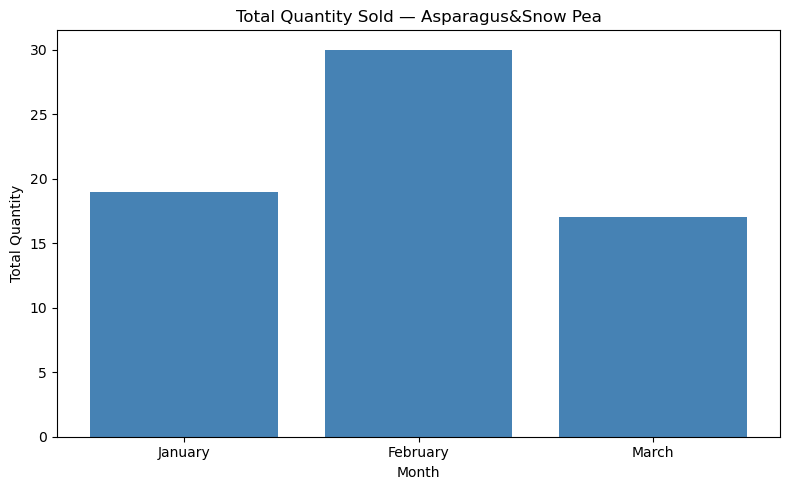

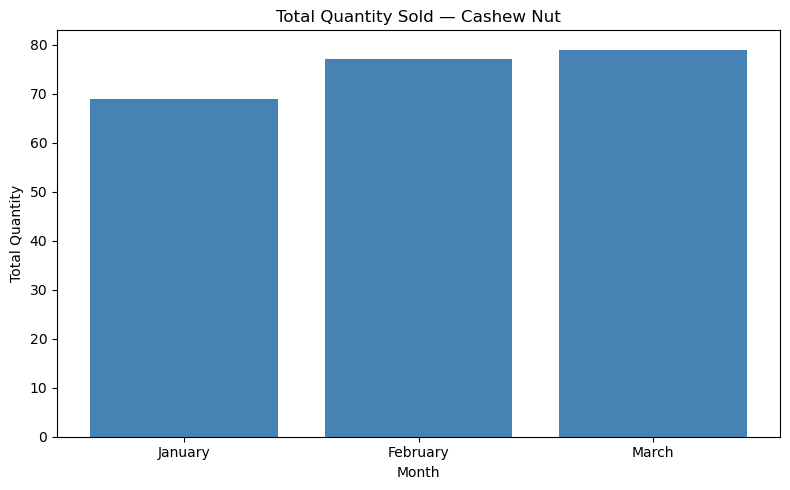

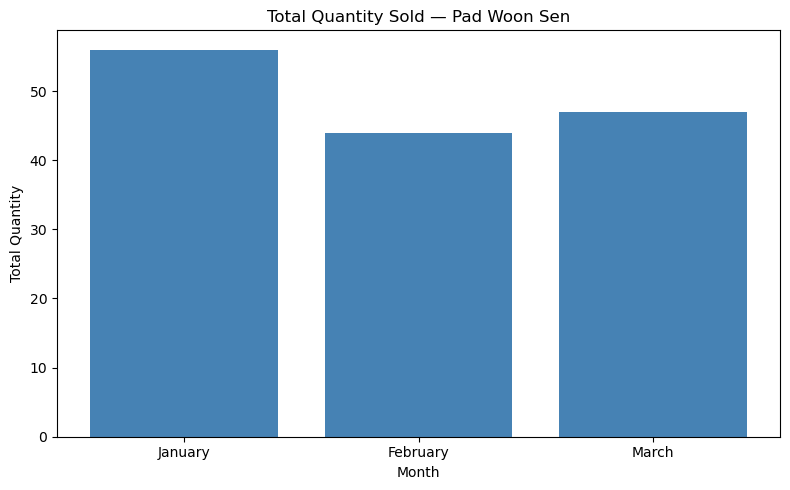

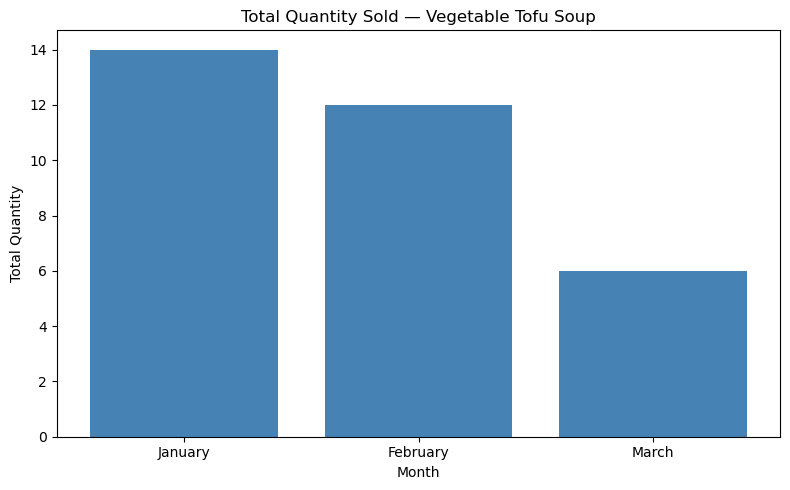

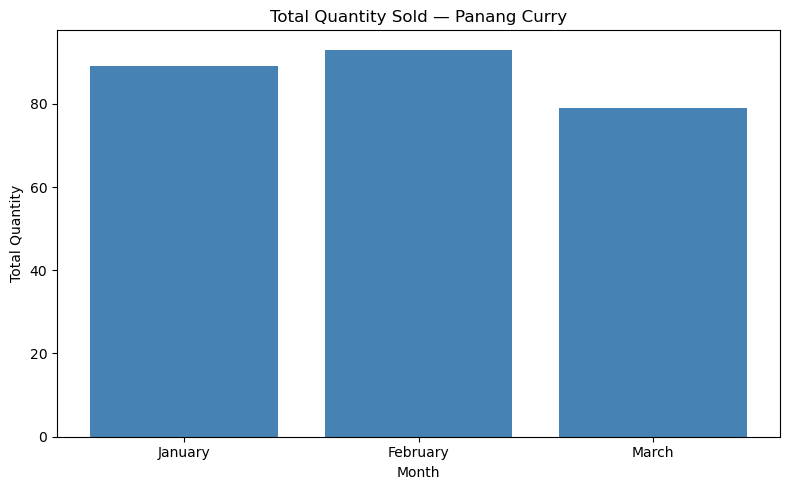

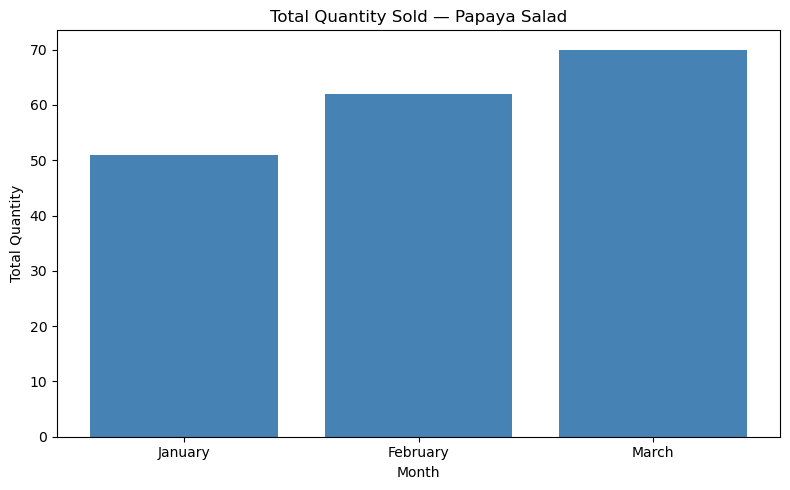

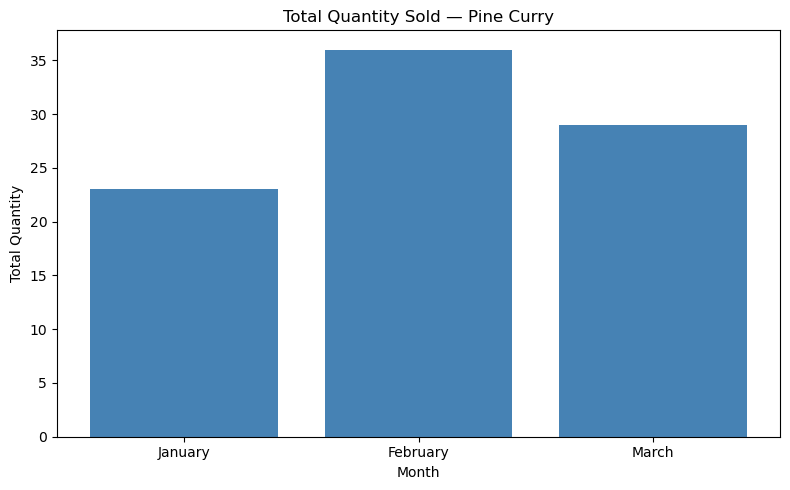

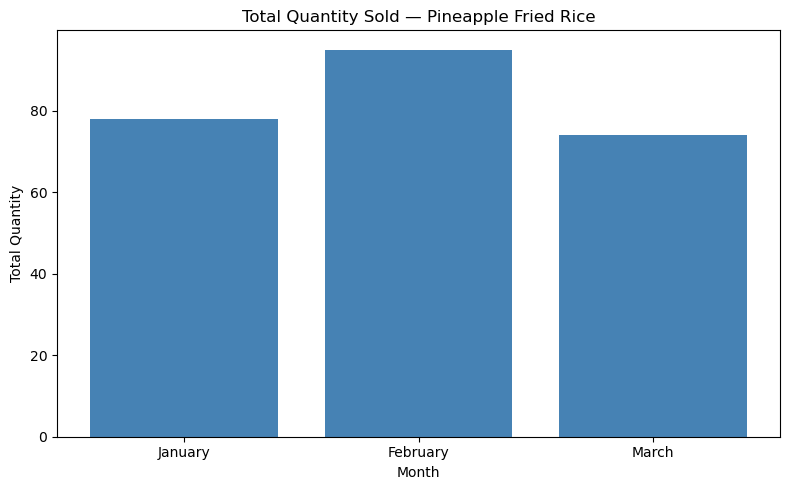

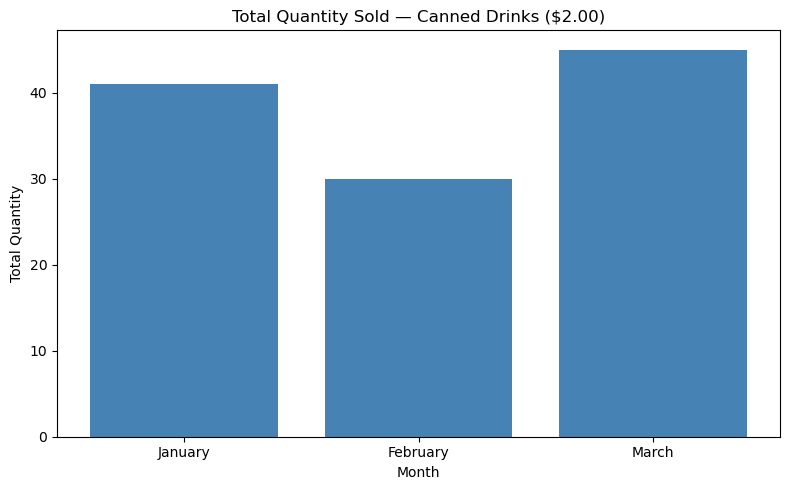

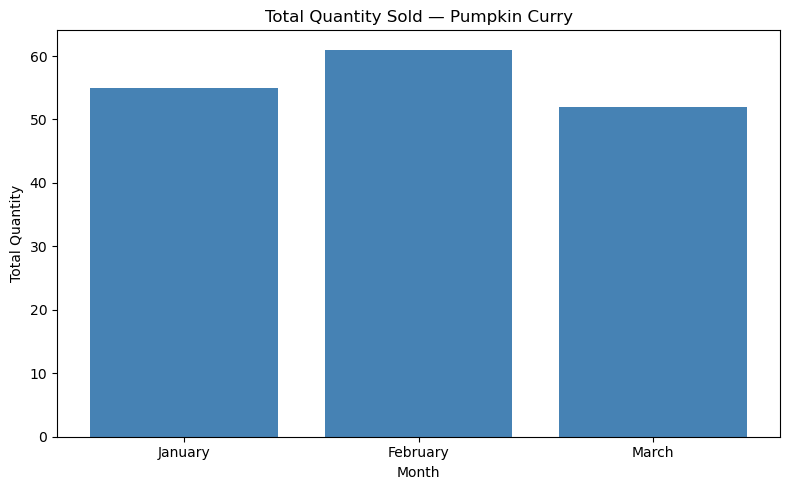

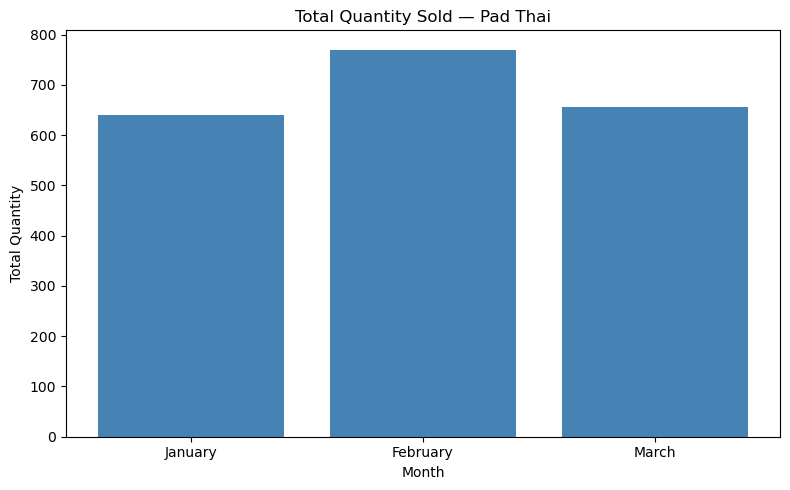

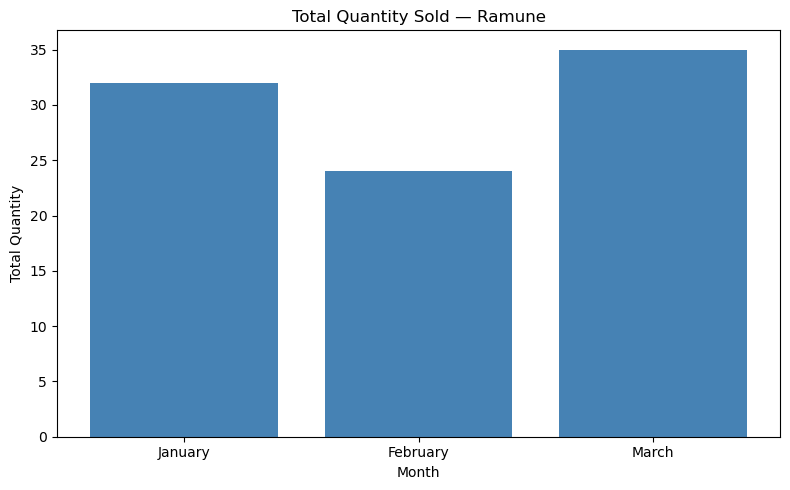

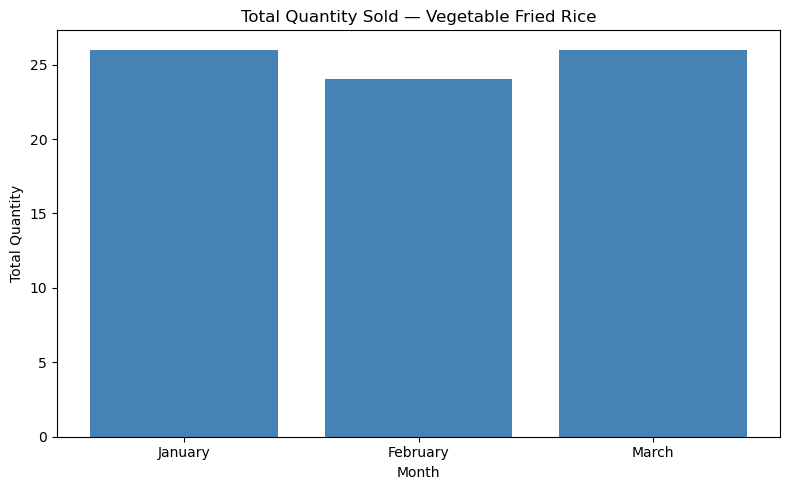

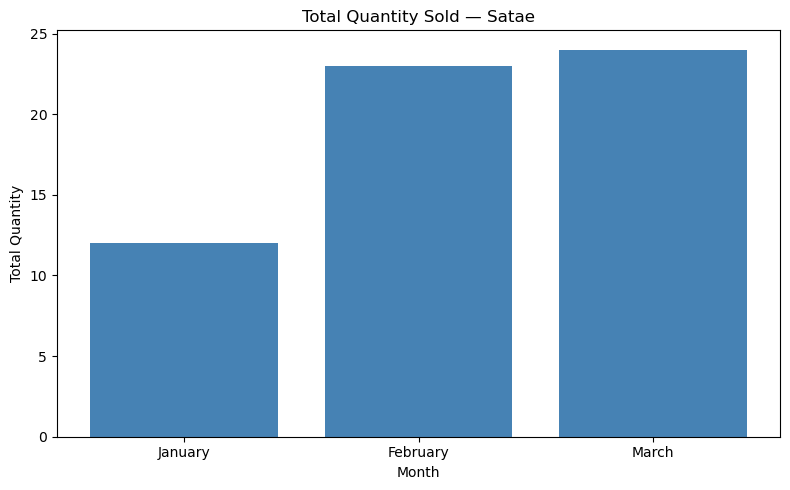

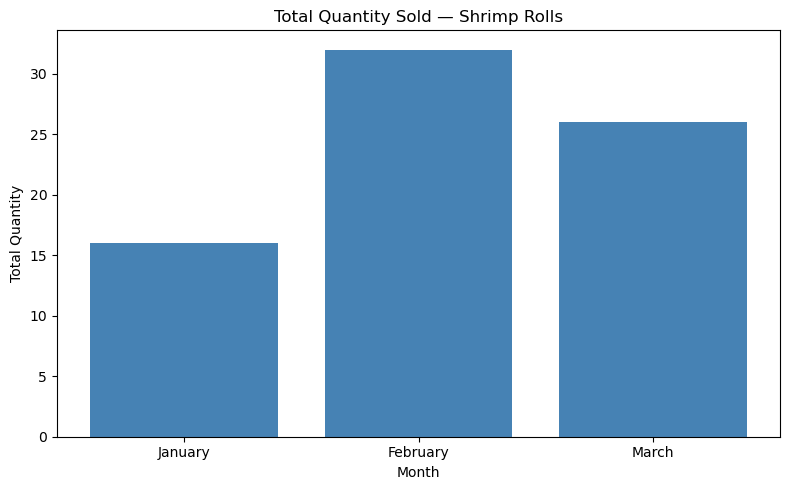

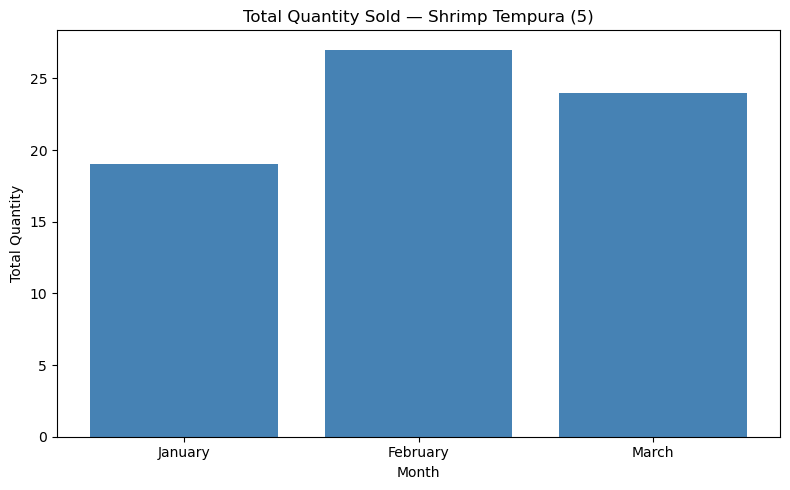

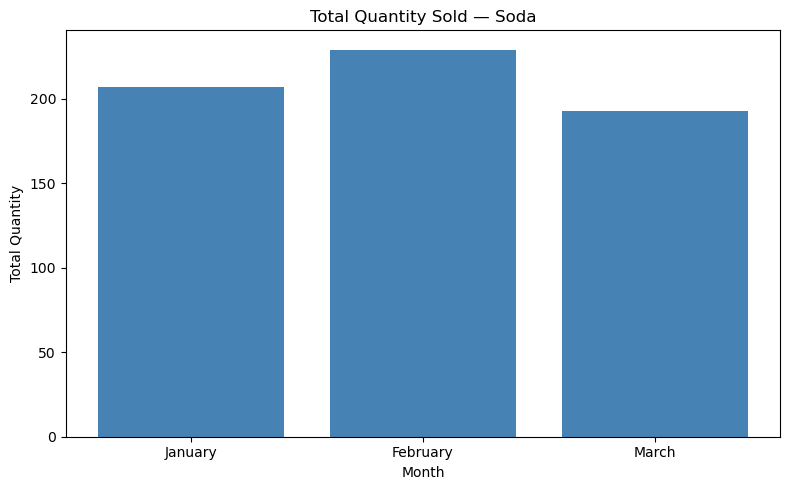

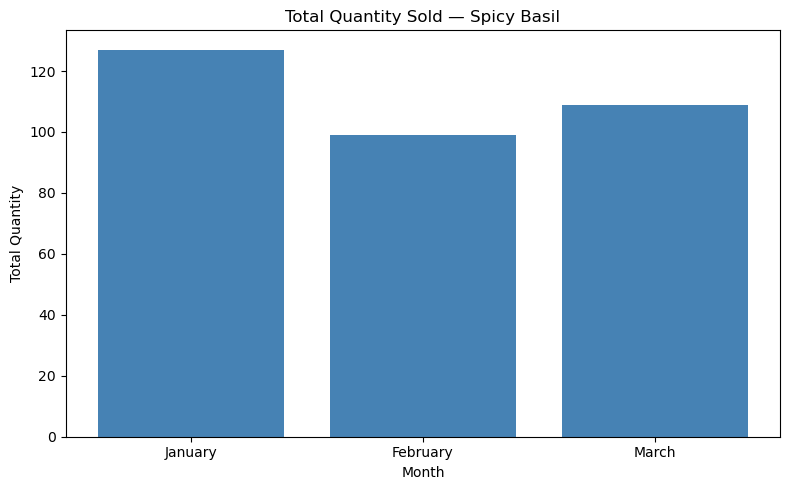

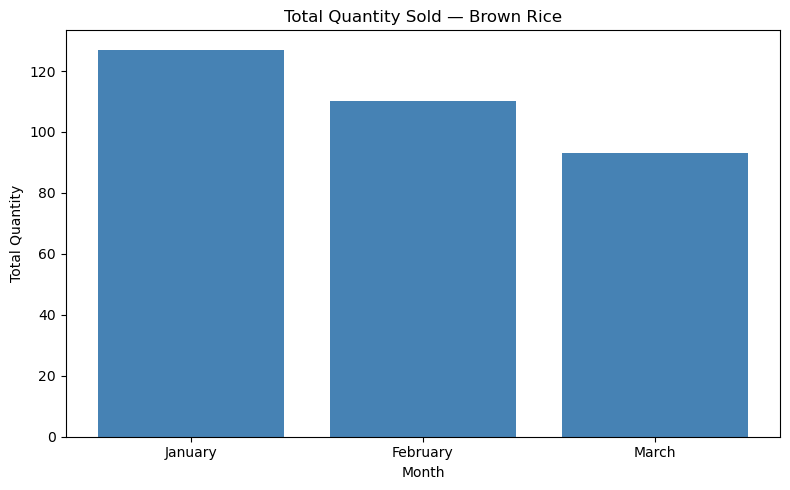

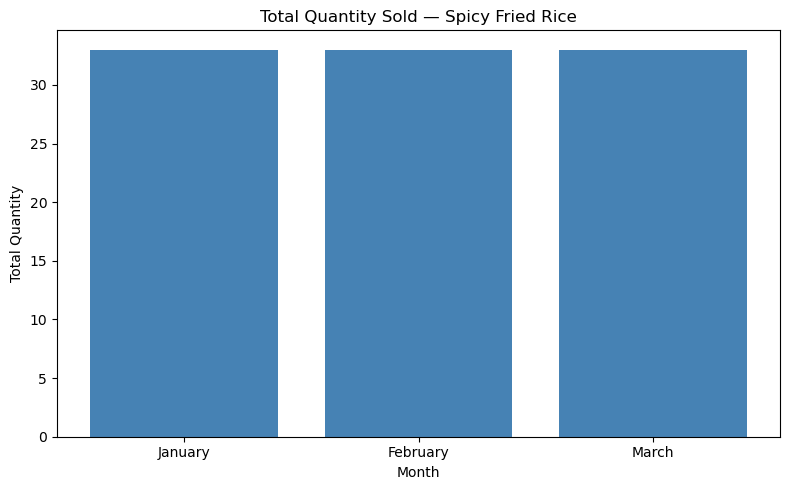

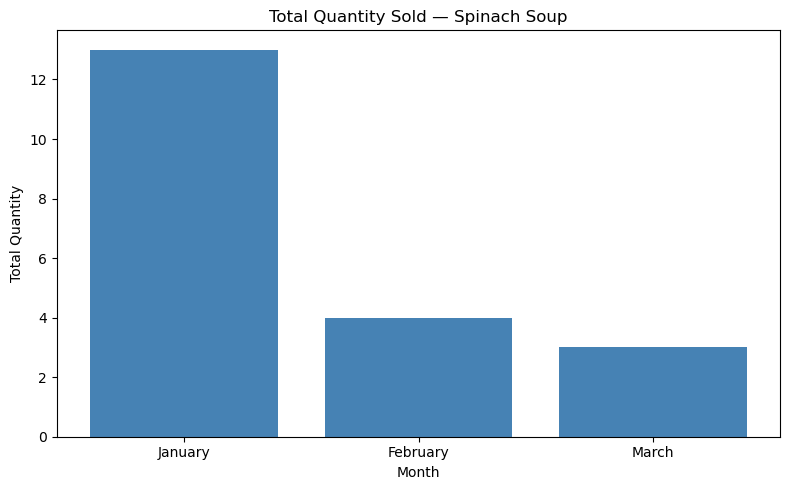

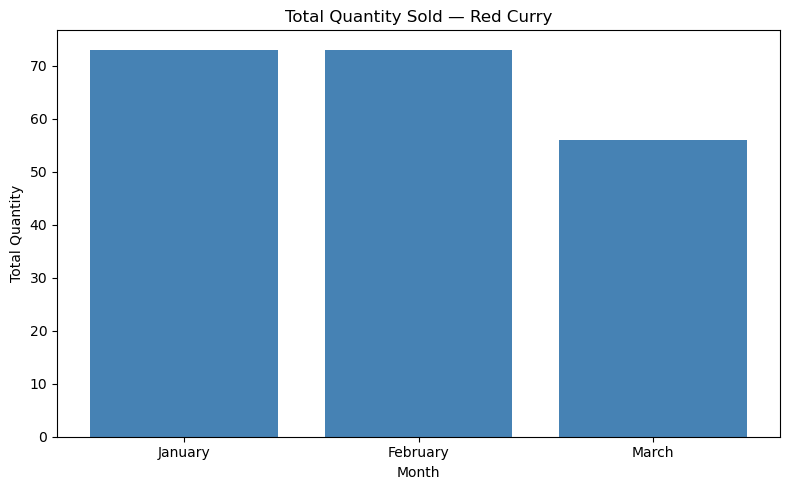

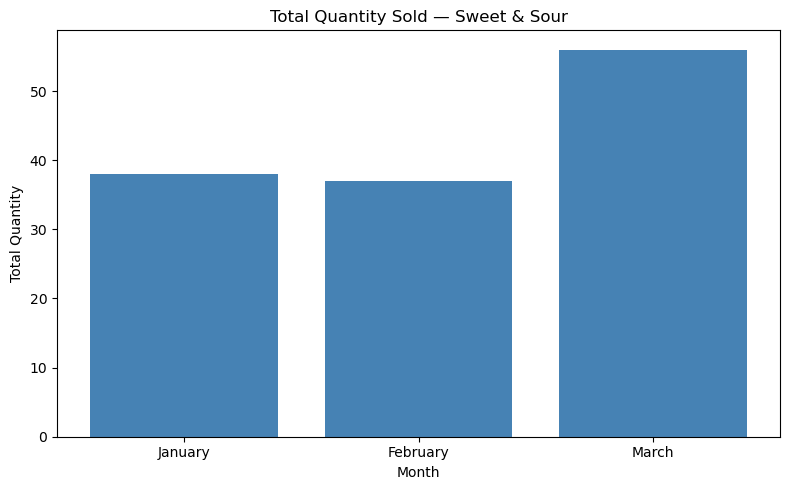

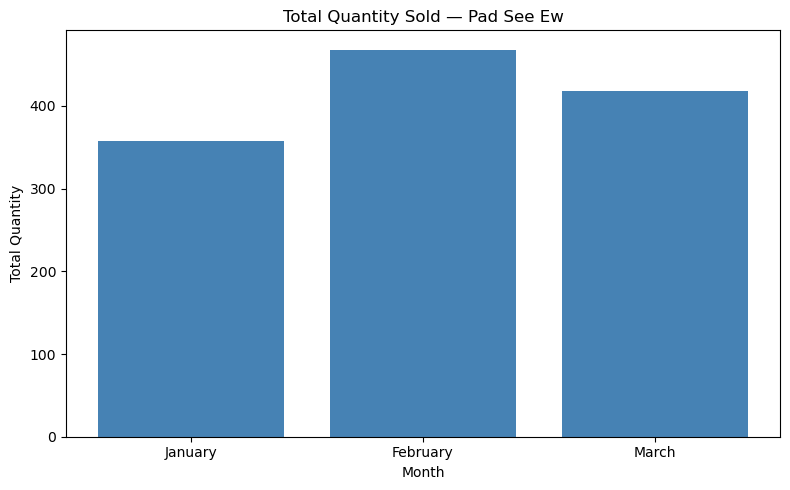

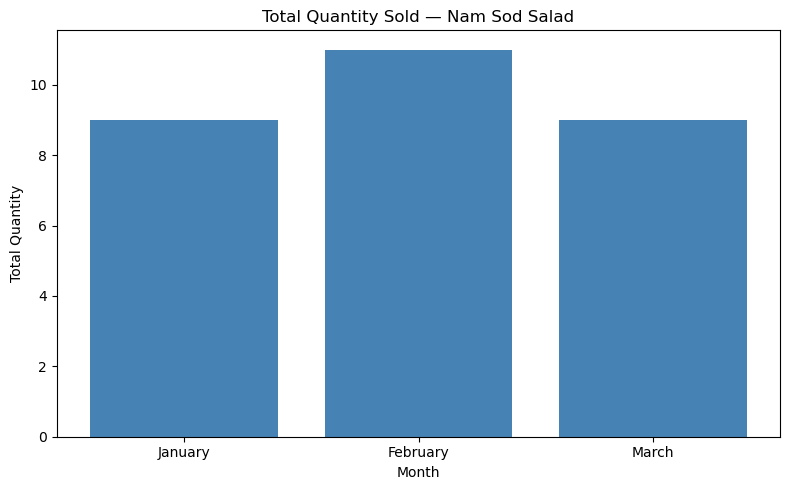

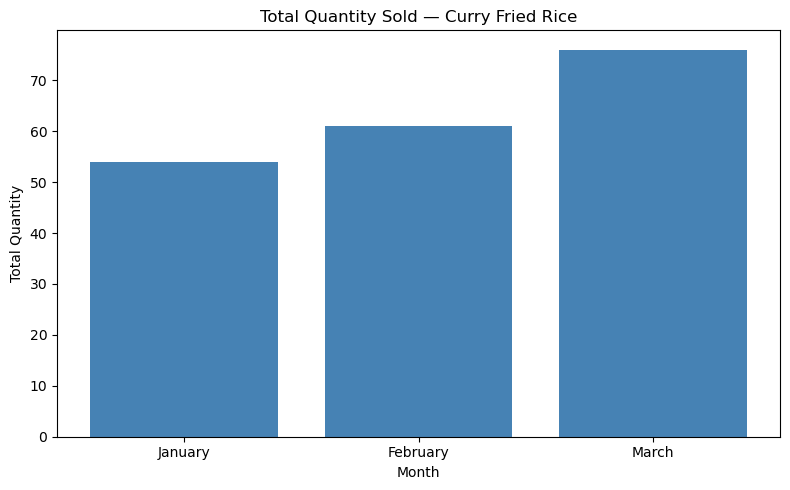

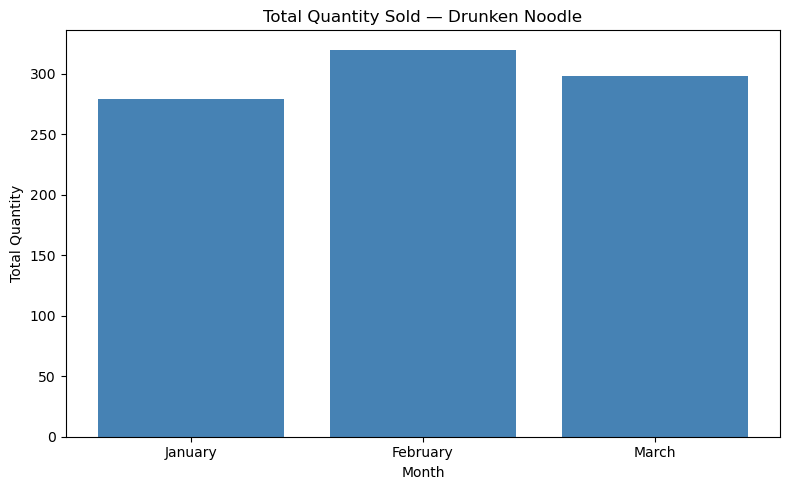

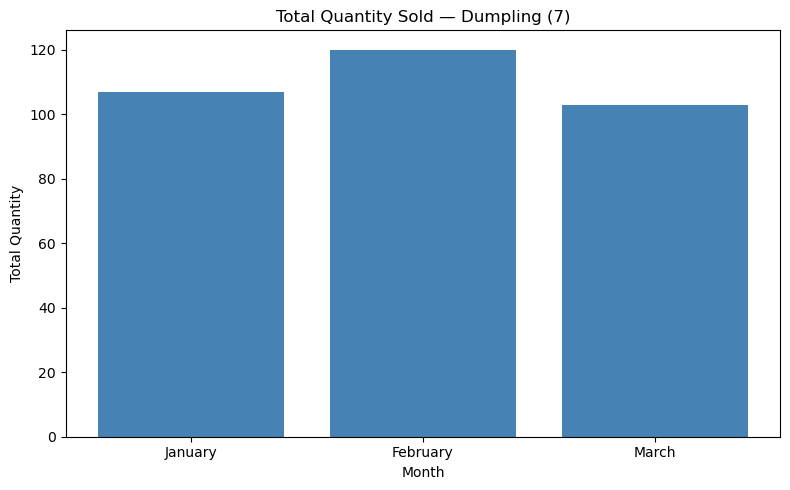

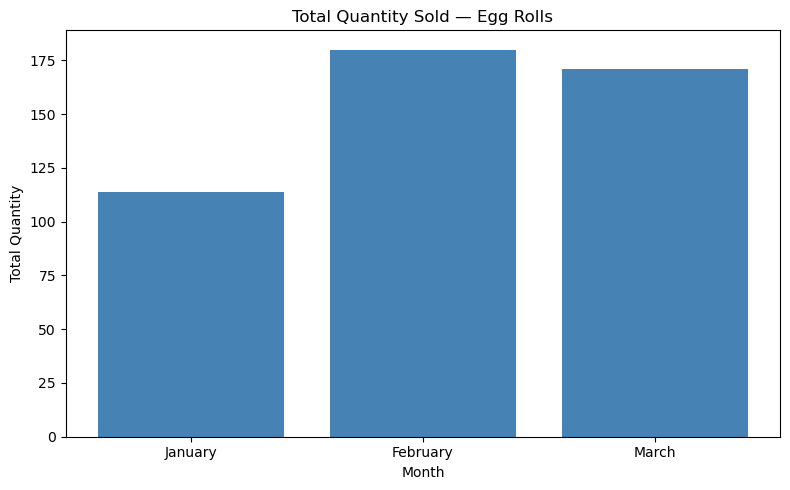

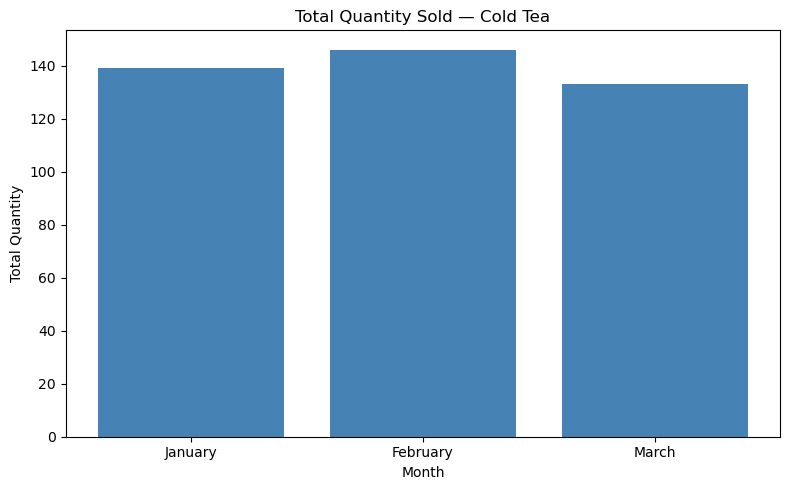

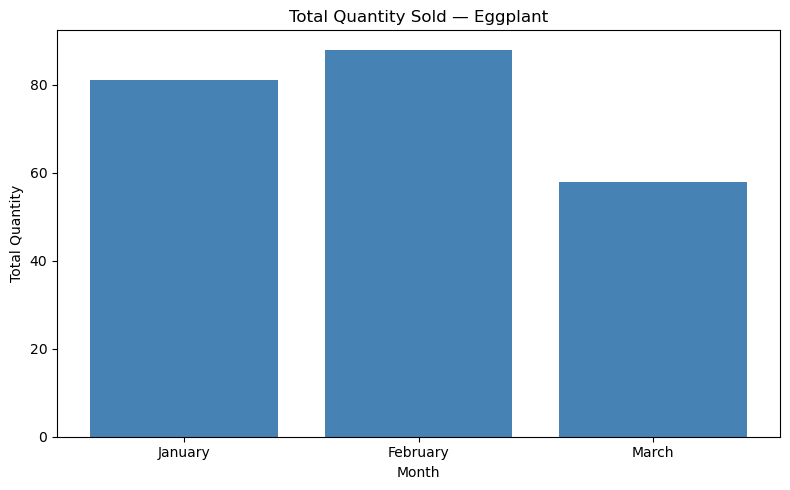

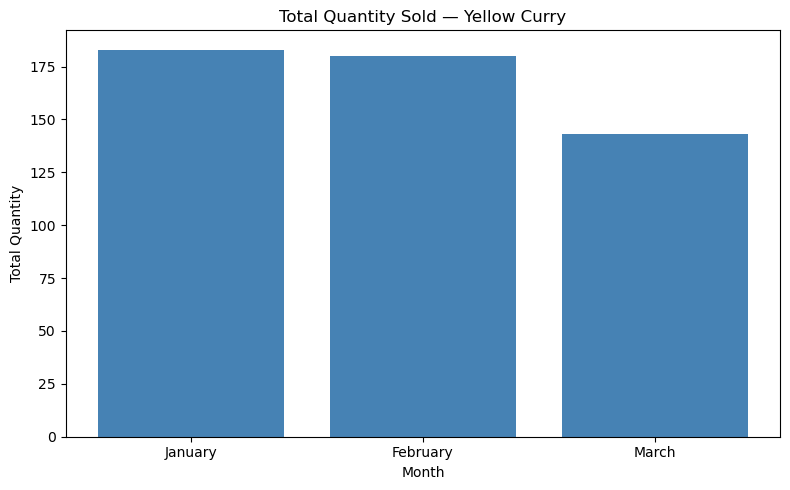

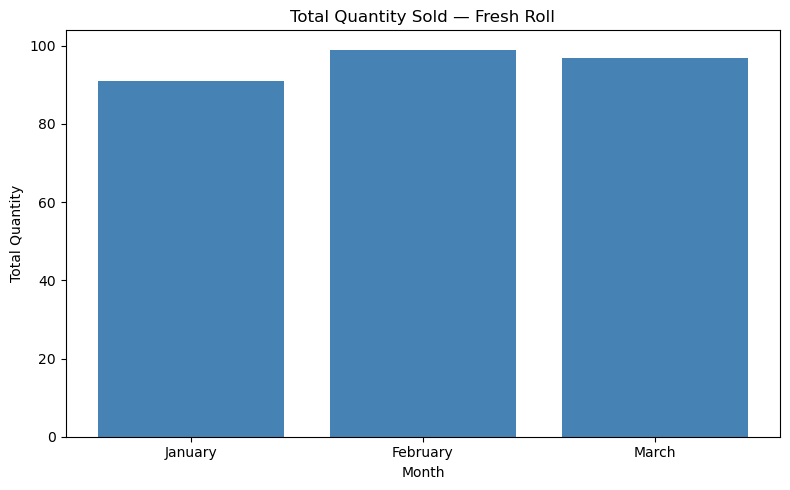

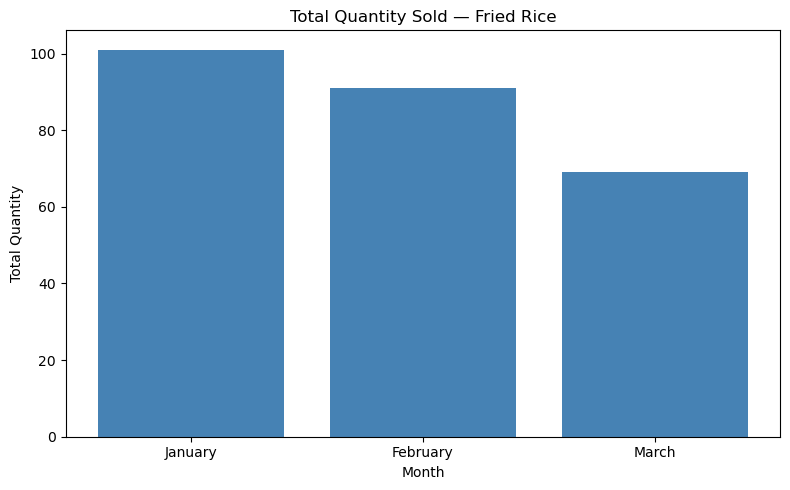

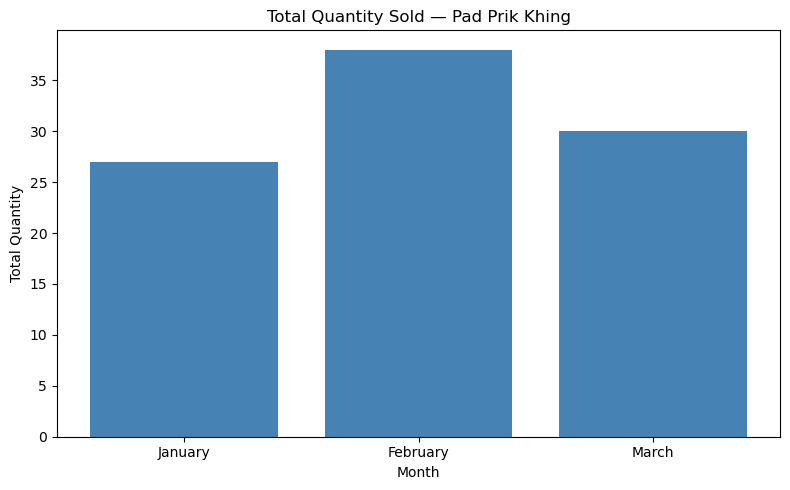

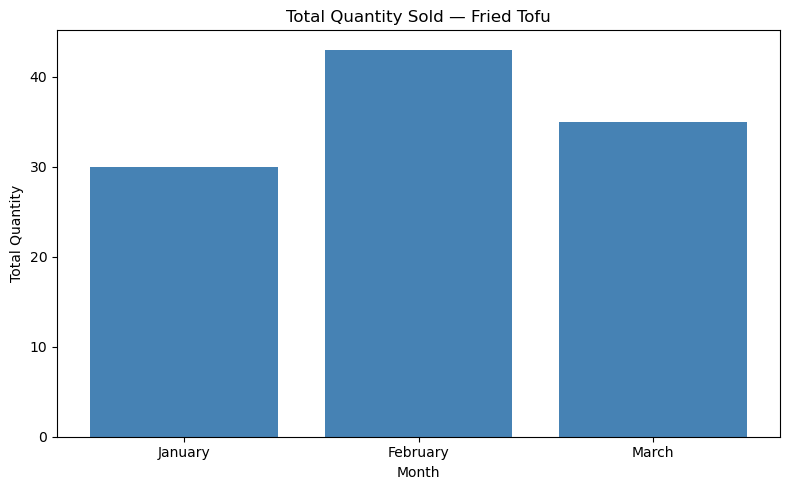

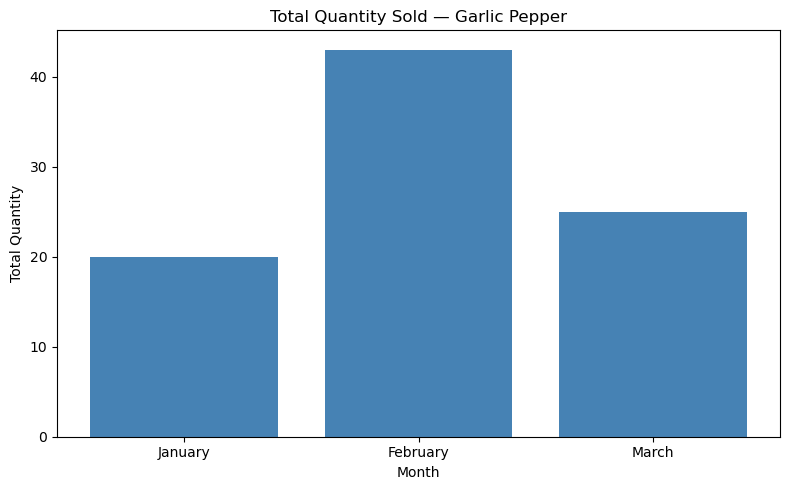

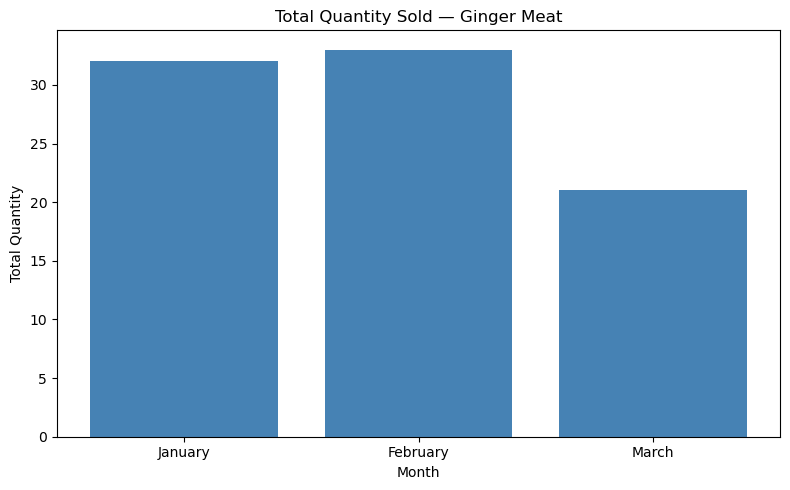

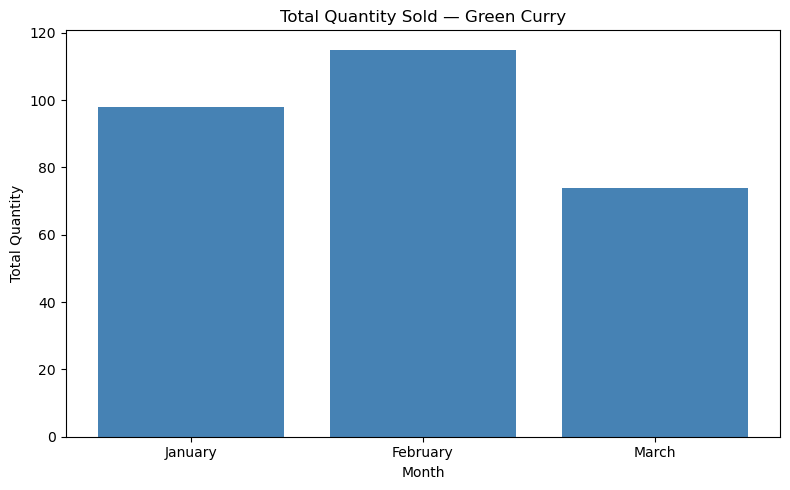

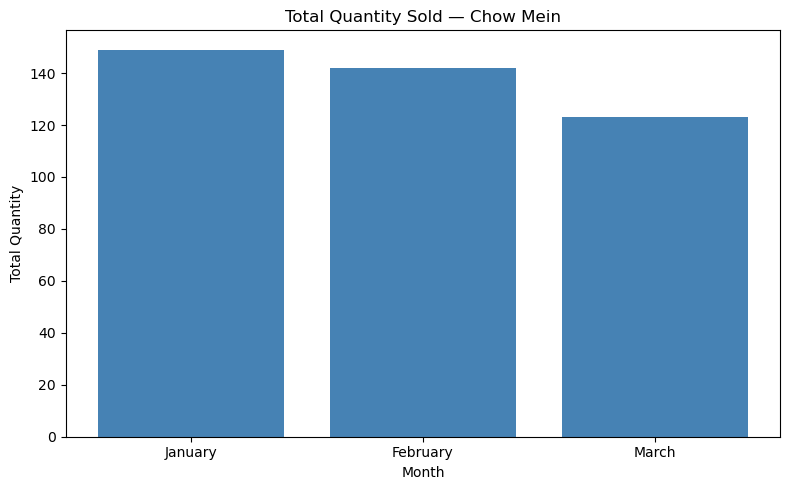

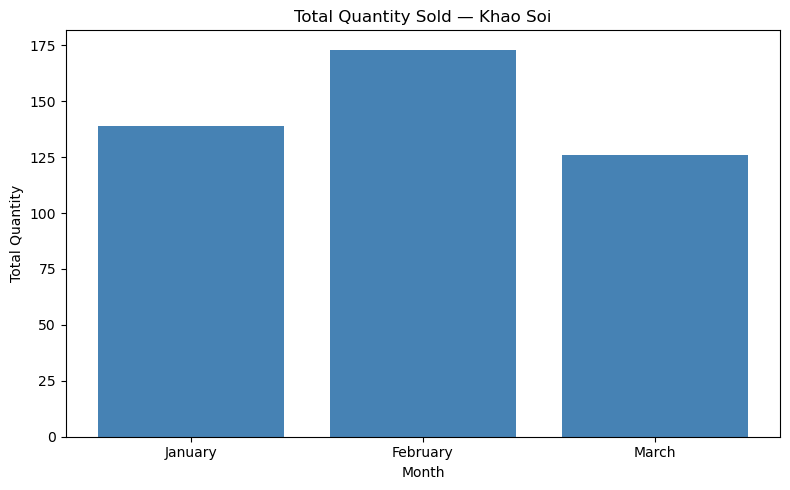

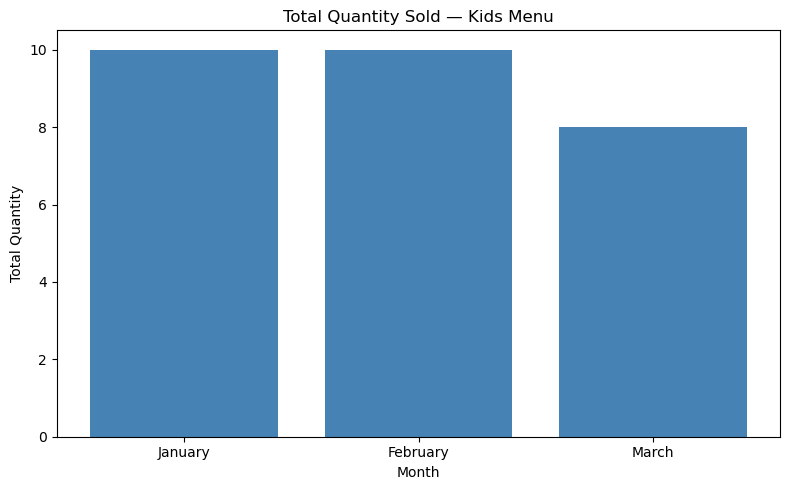

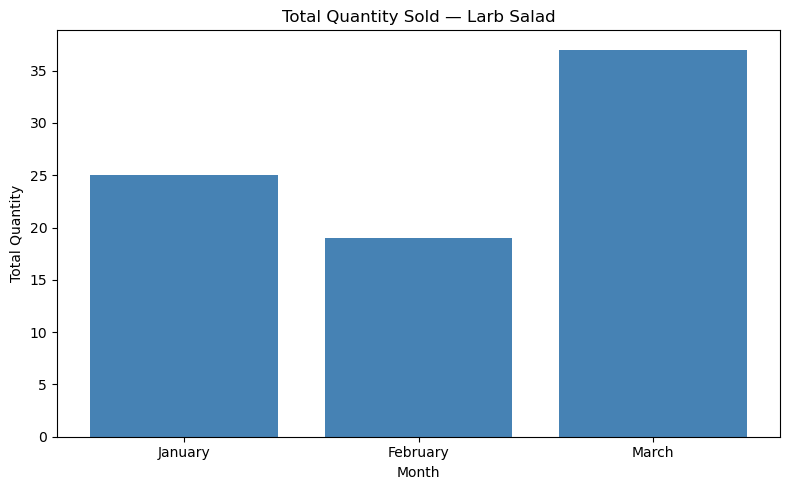

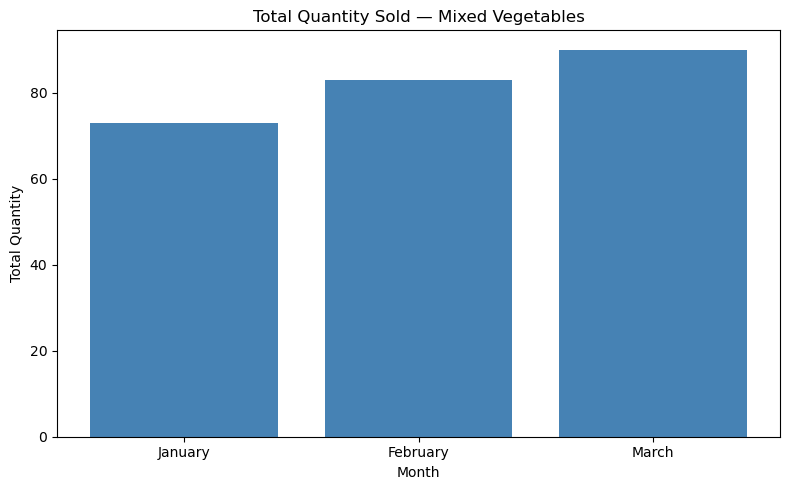

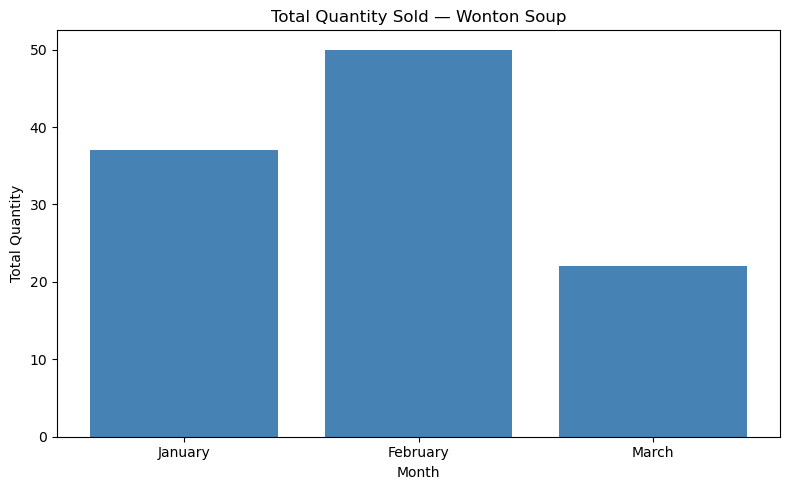

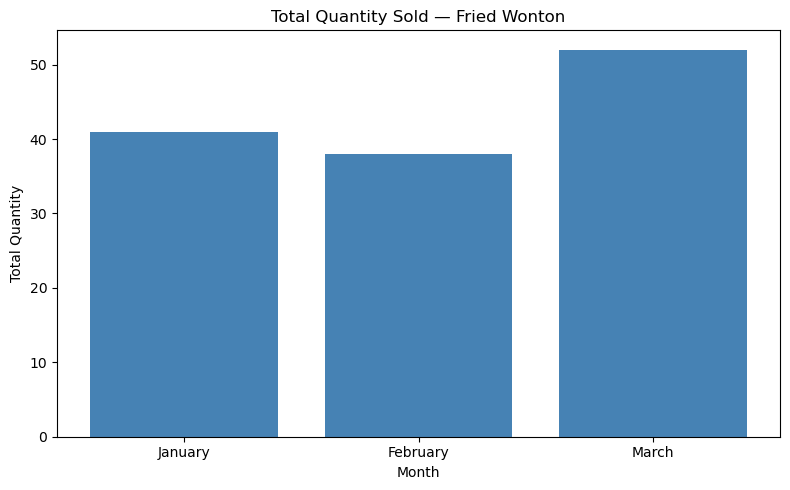

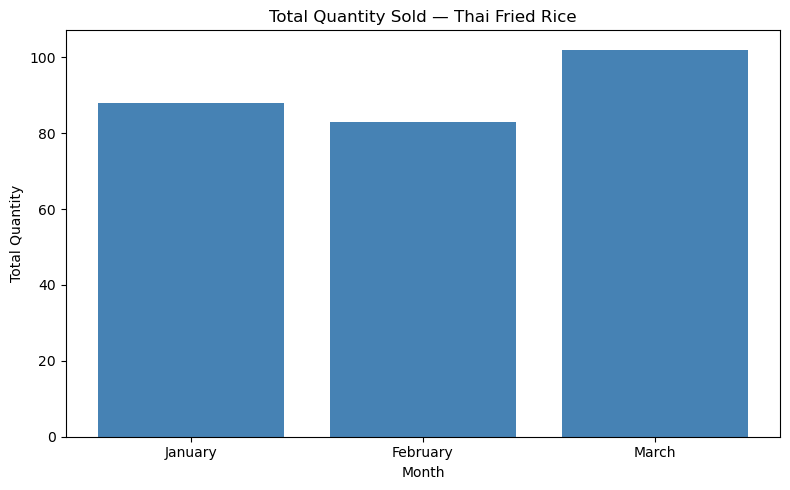

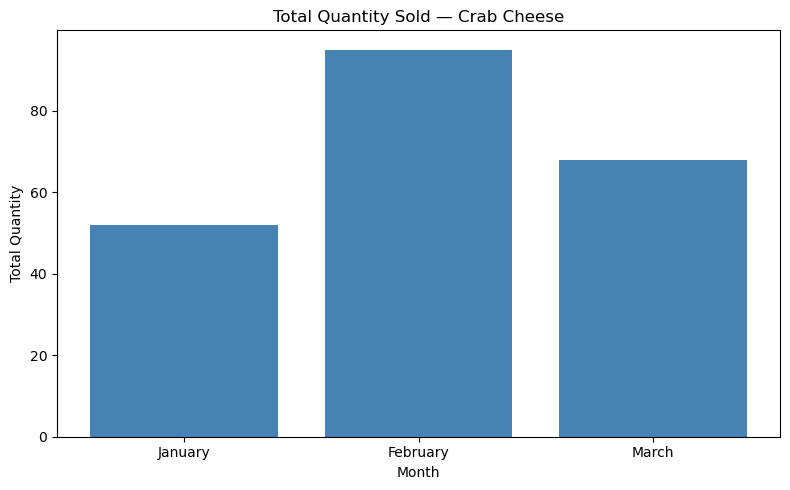

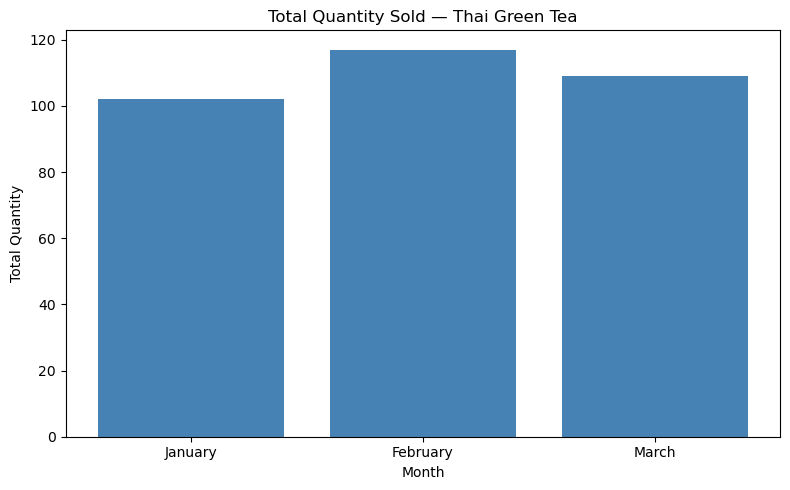

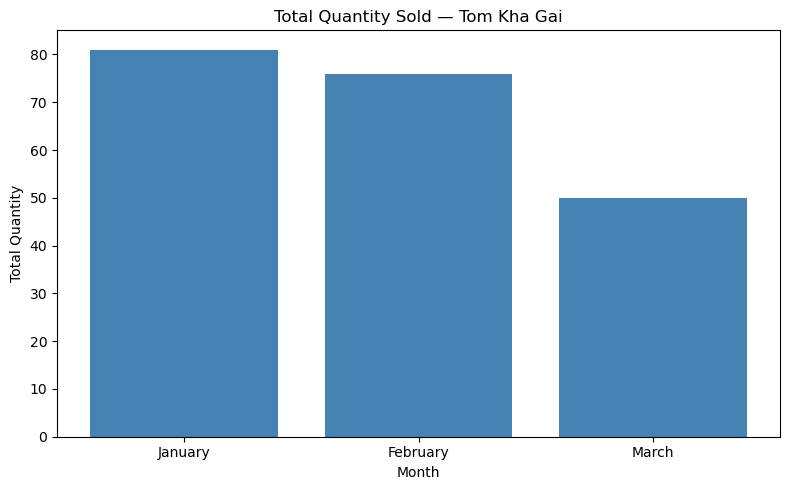

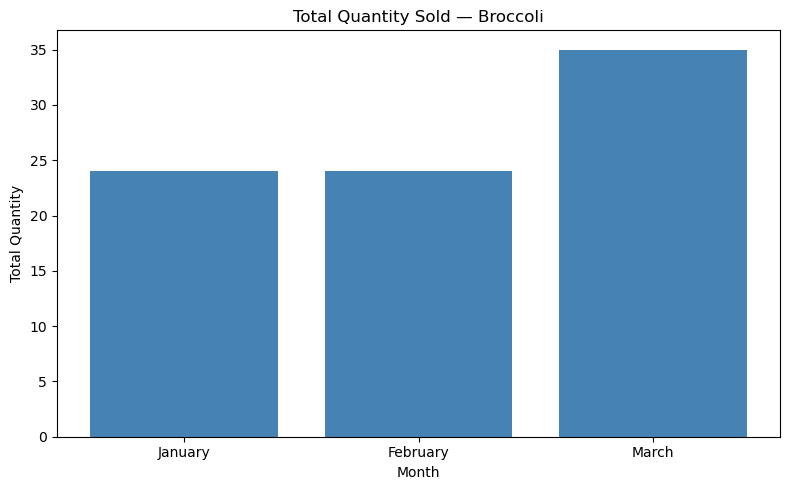

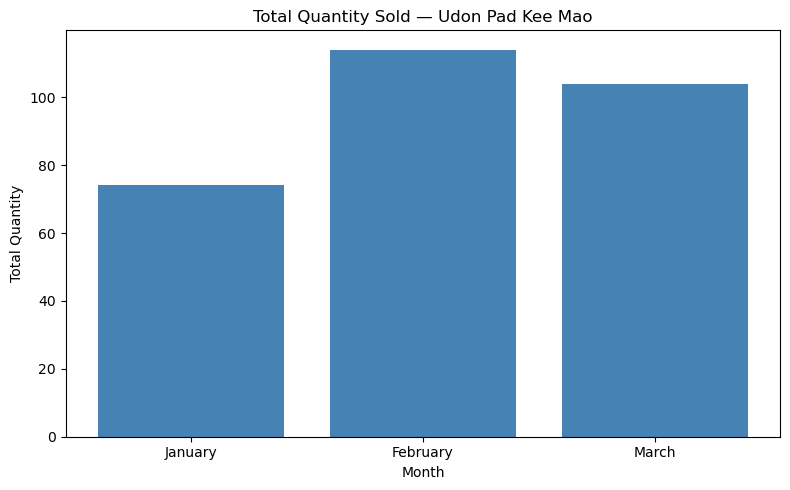

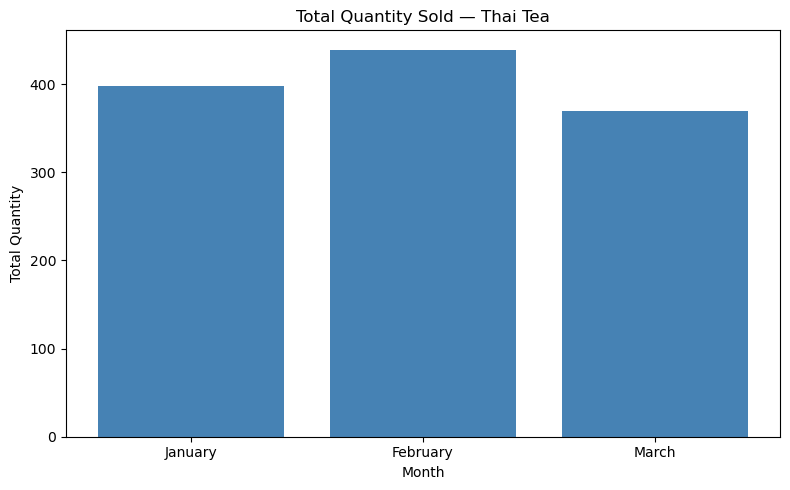

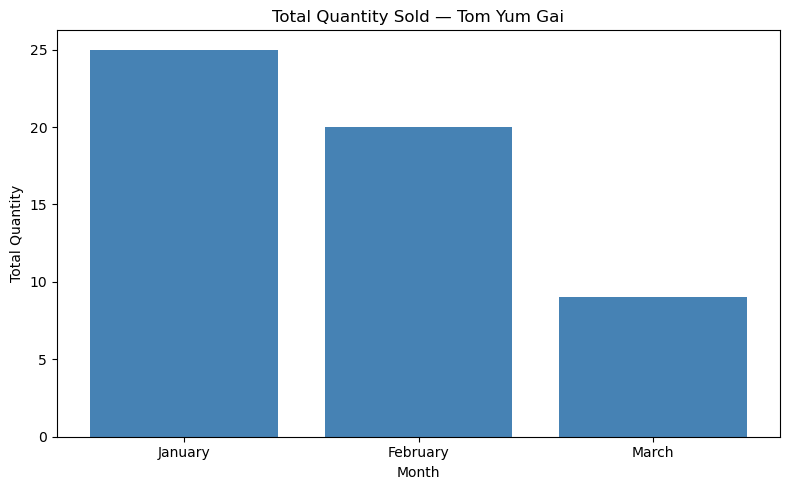

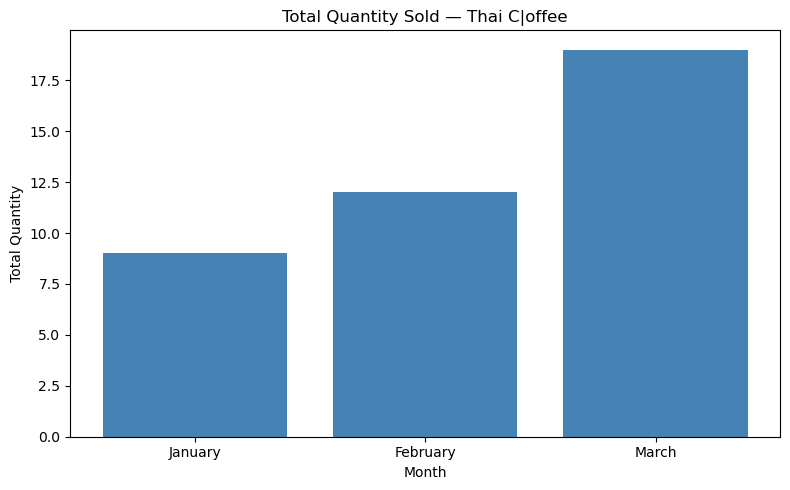

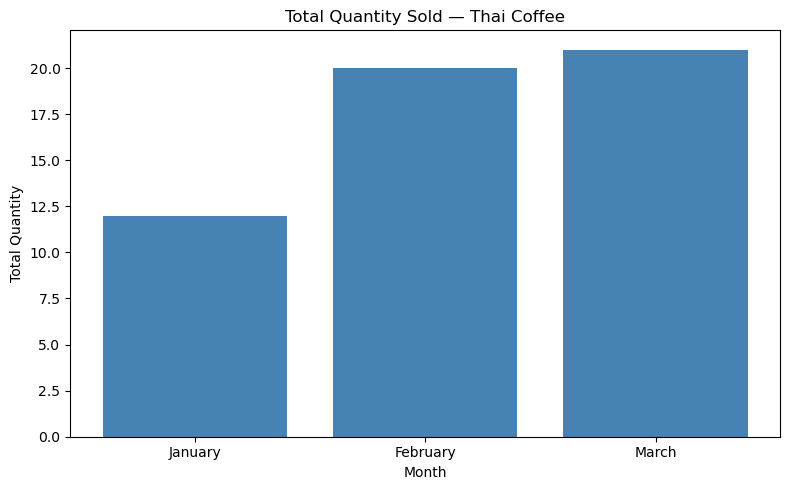

In [70]:
Items = df_update["Item"].unique()
for item in Items:
    plot_item_histogram(item)

**Interpretating the Data**
1. This is interesting to see, with many of the dishes having been more heavily sold in one month than the others.
2. I wonder what other factors contribute to weather or not a dish is sold or favored
3. Curry Fried Rice having been sold in one month

In [60]:
df_item = df_update.copy()
df_item["Month"] = pd.to_datetime(df_item["Date"]).dt.strftime("%B")

# Separate by month
df_jan = df_item[df_item["Month"] == "January"]
df_feb = df_item[df_item["Month"] == "February"]
df_mar = df_item[df_item["Month"] == "March"]

# Describe each month by item
jan_desc = (
    df_jan.groupby(["Item", "Date"])["Quantity"]
    .sum()
    .groupby("Item")
    .mean()
    .rename("Avg_Per_Day")
    .round(2)
    .to_frame()
)

feb_desc = (
    df_feb.groupby(["Item", "Date"])["Quantity"]
    .sum()
    .groupby("Item")
    .mean()
    .rename("Avg_Per_Day")
    .round(2)
    .to_frame()
)

mar_desc = (
    df_mar.groupby(["Item", "Date"])["Quantity"]
    .sum()
    .groupby("Item")
    .mean()
    .rename("Avg_Per_Day")
    .round(2)
    .to_frame()
)

pd.set_option("display.max_rows", None)
print("=== January ===")
print(jan_desc)
print("\n=== February ===")
print(feb_desc)
print("\n=== March ===")
print(mar_desc)

=== January ===
                       Avg_Per_Day
Item                              
Asparagus&Snow Pea            1.58
Broccoli                      1.85
Brown Rice                    5.77
Canned Drinks ($2.00)         2.93
Cashew Nut                    3.29
Chow Mein                     6.77
Cold Tea                      6.32
Crab Cheese                   3.06
Curry Fried Rice              2.70
Drunken Noodle               12.68
Dumpling (7)                  4.86
Egg Rolls                     5.18
Eggplant                      3.68
Fresh Roll                    4.33
Fried Rice                    4.59
Fried Tofu                    1.88
Fried Wonton                  2.05
Garlic Pepper                 2.00
Ginger Meat                   1.88
Green Curry                   4.45
Khao Soi                      6.32
Kids Menu                     1.43
Larb Salad                    1.67
Mixed Vegetables              3.48
Nam Sod Salad                 1.12
Pad Prik Khing                1.69
Pad 

**Preparing for trained Data**

In [61]:
df_update["Date"] = pd.to_datetime(df_update["Date"])
date_range = pd.date_range(df_update["Date"].min(), df_update["Date"].max(), freq="D")
items = df_update["Item"].unique()

full_index = pd.MultiIndex.from_product([date_range, items], names=["Date", "Item"])
df_long = df_update.set_index(["Date", "Item"]).reindex(full_index, fill_value=0).reset_index()

In [62]:
df_long = df_long.sort_values(["Item", "Date"])

#Days since last ordered
df_long["Last Order"] = df_long.groupby("Item")["Quantity"].transform(lambda x: x.where(x > 0).ffill())

#Counts how many days since the dish was ordered
df_long["Days Since Last Order"] = df_long.groupby("Item").cumcount()
df_long["Last Ordered"] = df_long.groupby("Item")["Quantity"].transform(lambda x: x.where(x > 0).ffill())

df_long["7 Day Average"] = df_long.groupby("Item")["Quantity"].transform(lambda x: x.rolling(7, min_periods=1).mean())

df_long["30 Day Average"] = df_long.groupby("Item")["Quantity"].transform(lambda x: x.rolling(30, min_periods=1).mean())

df_long["Day of Week"] = pd.to_datetime(df_long["Date"]).dt.dayofweek

df_long.head(5)

,Date,Item,Quantity,Sale,Last Order,Days Since Last Order,Last Ordered,7 Day Average,30 Day Average,Day of Week
54,2026-01-02,Asparagus&Snow Pea,1,18.25,1.0,0,1.0,1.000000,1.000000,4
110,2026-01-03,Asparagus&Snow Pea,0,0.00,1.0,1,1.0,0.500000,0.500000,5
166,2026-01-04,Asparagus&Snow Pea,3,51.75,3.0,2,3.0,1.333333,1.333333,6
222,2026-01-05,Asparagus&Snow Pea,0,0.00,3.0,3,3.0,1.000000,1.000000,0
278,2026-01-06,Asparagus&Snow Pea,0,0.00,3.0,4,3.0,0.800000,0.800000,1


In [64]:
popularity = df_long.groupby("Item")["Quantity"].agg(
    Total="sum",
    Days_Ordered=lambda x: (x > 0).sum(),
    Avg_Per_Day="mean"
).reset_index()

threshold = df_long["Date"].nunique() * 0.2
popularity["Popular"] = popularity["Days_Ordered"] >= threshold

print(popularity.sort_values("Total"))

                     Item  Total  Days_Ordered  Avg_Per_Day  Popular
42           Spinach Soup     20            14     0.229885    False
21              Kids Menu     28            19     0.321839     True
24          Nam Sod Salad     29            25     0.333333     True
53    Vegetable Tofu Soup     32            27     0.367816     True
45           Thai C|offee     40            30     0.459770     True
44            Thai Coffee     53            40     0.609195     True
50            Tom Yum Gai     54            37     0.620690     True
36                  Satae     59            42     0.678161     True
0      Asparagus&Snow Pea     66            43     0.758621     True
38     Shrimp Tempura (5)     70            41     0.804598     True
37           Shrimp Rolls     74            42     0.850575     True
52   Vegetable Fried Rice     76            41     0.873563     True
22             Larb Salad     81            50     0.931034     True
1                Broccoli     83  

**Inferences Made about Dishes Sold (3 Month)**
This shows how the past 3 month if dishes were sold more than 20% of the 3 months, it indicates if the dish was a seller or not. As we see here most of the dishes are quite popular in the resturant with many selling well over a hundred and reaching a thousand sold. Notable dishes in the menu are Thai tea (1206 sold), Pad See Ew (1244 sold), and Pad Thai (2066 sold). The only notable item in the menu that isn't sold is Spinach soup. 